# Gradient Descent on the Rosenbrock Function With Momentum

In [66]:
import numpy as np
def rosenbrock(x,y):
    return (1-x)**2 + 100*(y-x**2)**2
# Gradient of the Rosenbrock function
def grad_rosenbrock(w):
    x= w[0]
    y= w[1]
    return np.array([-2*(1-x)-400*x*(y-x**2),200*(y-x**2)])


## Standard Gradient Descent

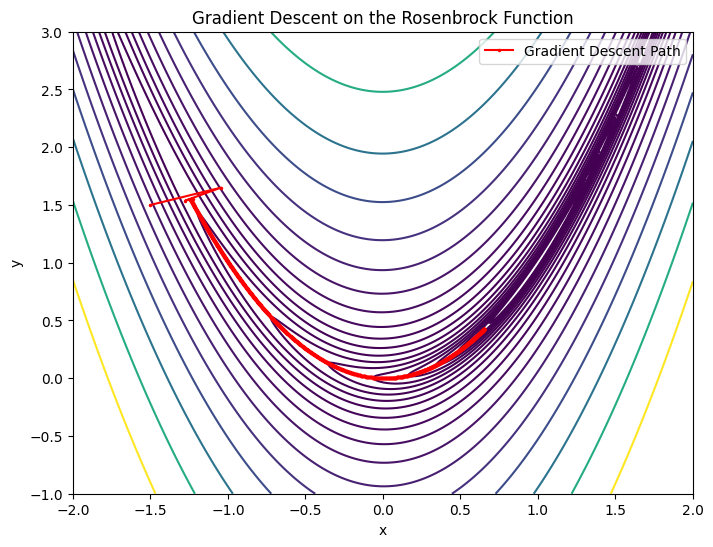

[0.65438141 0.42654496]
[-0.25409319 -0.33401315]


In [124]:
import matplotlib.pyplot as plt

num_iters = 2000
# Initial point on the gradient descent
init = np.array([-1.5,1.5],dtype=float)
w = init.copy()
l_r = .001

path = [w.copy()]

for _ in range(num_iters):
    w -= l_r *grad_rosenbrock(w)
    path.append(w.copy())
path = np.array(path)
X = np.linspace(-2,2,400)
Y = np.linspace(-1,3,400)
XX, YY = np.meshgrid(X, Y)
ZZ = rosenbrock(XX,YY)
plt.figure(figsize=(8, 6))
plt.contour(XX, YY, ZZ, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(path[:,0],path[:,1], 'r.-', markersize=3, label='Gradient Descent Path')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent on the Rosenbrock Function')
plt.legend()
plt.show()
standard_w = w
standard_grad = grad_rosenbrock(w)
print(w)
print(grad_rosenbrock(w))

## Gradient Descent with Momentum

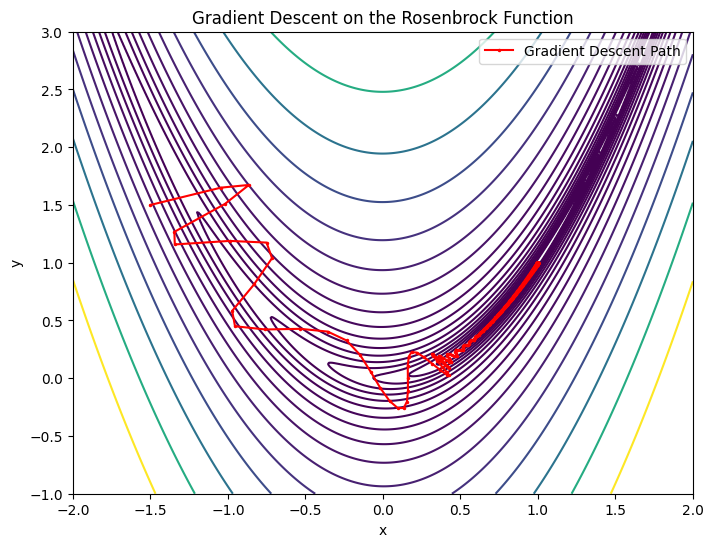

Standard gradient descent w:[0.65438141 0.42654496]
Standard final gradient:[-0.25409319 -0.33401315]
Momentum w:[0.99992133 0.99984235]
Momentum gradient:[-3.14223117e-05 -6.29656335e-05]


In [110]:
import math
num_iters = 2000
init = np.array([-1.5,1.5],dtype=float)
w = init.copy()
l_r = .001
beta = .9
path = [w.copy()]
V = 0
min = float('inf')

for _ in range(num_iters):
    V = beta*V - l_r *grad_rosenbrock(w)
    w += V
    path.append(w.copy())
path = np.array(path)
X = np.linspace(-2,2,400)
Y = np.linspace(-1,3,400)
XX, YY = np.meshgrid(X, Y)
ZZ = rosenbrock(XX,YY)
plt.figure(figsize=(8, 6))
plt.contour(XX, YY, ZZ, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(path[:,0],path[:,1], 'r.-', markersize=3, label='Gradient Descent Path')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent on the Rosenbrock Function')
plt.legend()
plt.show()
print(f'Standard gradient descent w:{standard_w}\nStandard final gradient:{standard_grad}\nMomentum w:{w}\nMomentum gradient:{grad_rosenbrock(w)}')

### Findings 
The standard gradient descent got trapped in the local minima located at [0.65438141 0.42654496] which is far from the global minimum of [1,1]. The momentum added managed to push the resulting gradient descent past that local minima towards the global